# 03 — Main (simulation + pricing = full set)
Connects both systems: simulates each scenario once (`01` engine via `voltvision/`), prices the same book three ways (`02` regimes), compares side by side. Then figures, TPO diagnostic, optional Monte Carlo, Excel export.

Run top to bottom. Only touch the config cell. (`04_analysis.ipynb` comes later as complement.)

In [1]:
import copy, os, sys
ROOT = os.path.abspath('')
if ROOT not in sys.path: sys.path.insert(0, ROOT)

import pandas as pd
import matplotlib.pyplot as plt
from voltvision import CFG, SCEN, N_YEARS, REGIMES
from voltvision import gen, simulate, price_many, price_book, summary, lr, lr_by, reg_color, reg_label
from voltvision import ensure_core_methods
from voltvision import io
ensure_core_methods()  # load CALC cells from 02a/02b/02c
%matplotlib inline


## Config (only cell you need to touch)

In [2]:
VEH = "ALL"   # "ICE" | "EV" | "MIX" | "ALL"
QUICK = False  # True -> n=1000, 2 years (smoke test)

cfg = copy.deepcopy(CFG)
if QUICK:
    cfg['n'] = 1000
scens = [VEH] if VEH in SCEN else ["ICE", "EV", "MIX"]
REGIMES_RUN = list(REGIMES)  # add registered names here for N-regime runs
nyears = 2 if QUICK else N_YEARS
print(scens, '| n =', cfg['n'], '| years =', nyears)


['ICE', 'EV', 'MIX'] | n = 10000 | years = 5


## Results — 100% ICE vs 100% EV vs MIX (all three regimes, side by side)

In [3]:
ALL = {}
for s in scens:
    vp = SCEN[s]
    d0 = gen(cfg, vp, cfg['seed'])
    book = simulate(d0, cfg, vp, seed=cfg['seed'], n_years=nyears, verbose=True)
    io.save_sim(s, book)
    books = price_many(book, cfg, REGIMES_RUN)
    for m, b in books.items():
        io.save_priced(s, m, b)
    ALL[s] = (book, books)
    print(f"\n=== {s} {vp} ===")
    display(summary(books))
    print("LR by coverage (rows=coverage, cols=regime):")
    display(pd.DataFrame({m: lr_by(b, 'COVERAGE_TYPE').round(1) for m, b in books.items()}))
print("\nLR by vehicle (MIX book, all 3 regimes):")
if "MIX" in ALL:
    display(pd.DataFrame({m: lr_by(b, 'VEHICLE_TYPE').round(1) for m, b in ALL["MIX"][1].items()}))


Year 2026: 10000 pols, claims 1827, freq 16.2%
Year 2027: 13805 pols, claims 2517, freq 16.5%
Year 2028: 17180 pols, claims 3118, freq 16.4%
Year 2029: 20264 pols, claims 3546, freq 15.9%
Year 2030: 23029 pols, claims 4087, freq 16.1%

=== ICE {'ICE': 1.0, 'EV': 0.0} ===


,Regime,LR (%),Avg prem (RM),Prem-count rho
0,Tariff,73.02,1442.0,0.364
1,GLM,61.75,1705.0,0.637
2,GLM+Telematics,61.81,1704.0,0.637


LR by coverage (rows=coverage, cols=regime):


,tariff,glm,telem
COVERAGE_TYPE,,,
Comprehensive,61.3,60.6,60.7
TPFT,102.1,62.6,62.6
TPO,143.3,66.9,66.9


Year 2026: 10000 pols, claims 1930, freq 17.1%
Year 2027: 13752 pols, claims 2597, freq 17.1%
Year 2028: 17117 pols, claims 3236, freq 17.1%
Year 2029: 20136 pols, claims 3752, freq 16.8%
Year 2030: 22857 pols, claims 4310, freq 17.0%

=== EV {'ICE': 0.0, 'EV': 1.0} ===


...

,Regime,LR (%),Avg prem (RM),Prem-count rho
0,Tariff,74.45,1515.0,0.361
1,GLM,61.47,1835.0,0.640
2,GLM+Telematics,61.52,1834.0,0.640


LR by coverage (rows=coverage, cols=regime):


,tariff,glm,telem
COVERAGE_TYPE,,,
Comprehensive,62.3,60.6,60.6
TPFT,103.0,62.1,62.2
TPO,153.6,65.5,65.7



LR by vehicle (MIX book, all 3 regimes):


,tariff,glm,telem
VEHICLE_TYPE,,,
EV,75.2,61.4,61.7
ICE,74.3,61.5,61.5


In [4]:
for s in scens:
    book, books = ALL[s]
    tpo = {m: books[m][books[m].COVERAGE_TYPE == 'TPO'] for m in REGIMES_RUN}
    print(f"--- {s}: TPO avg prem / avg sev-per-claim / TPO LR (3 regimes) ---")
    display(pd.DataFrame([{'Regime': reg_label(m),
        'Avg prem (RM)': round(tpo[m]['FINAL_PREMIUM_SST'].mean(), 0),
        'Sev/claim (RM)': round(tpo[m][tpo[m].CLAIM_COUNT > 0]['CLAIM_AMOUNT'].mean(), 0),
        'TPO LR (%)': round(lr(tpo[m]), 1)} for m in REGIMES_RUN]).set_index('Regime'))
print("Theory LR ~99%; actual tariff TPO LR higher because Gamma(0.35) tails + 5-yr compounding.")


--- ICE: TPO avg prem / avg sev-per-claim / TPO LR (3 regimes) ---


,Avg prem (RM),Sev/claim (RM),TPO LR (%)
Regime,,,
Tariff,565.0,9063.0,143.3
GLM,1210.0,9063.0,66.9
GLM+Telematics,1210.0,9063.0,66.9


--- EV: TPO avg prem / avg sev-per-claim / TPO LR (3 regimes) ---


,Avg prem (RM),Sev/claim (RM),TPO LR (%)
Regime,,,
Tariff,796.0,10187.0,123.2
GLM,1513.0,10187.0,64.8
GLM+Telematics,1512.0,10187.0,64.8


--- MIX: TPO avg prem / avg sev-per-claim / TPO LR (3 regimes) ---


,Avg prem (RM),Sev/claim (RM),TPO LR (%)
Regime,,,
Tariff,582.0,9537.0,153.6
GLM,1365.0,9537.0,65.5
GLM+Telematics,1361.0,9537.0,65.7


Theory LR ~99%; actual tariff TPO LR higher because Gamma(0.35) tails + 5-yr compounding.


## Three required figures (every panel = 3 regimes)

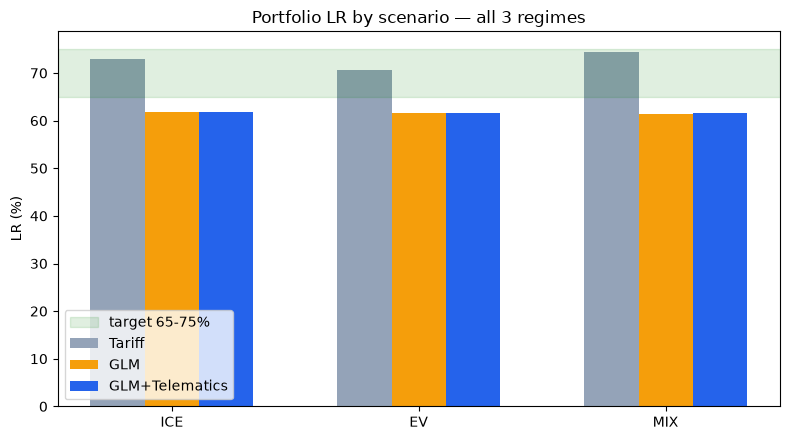

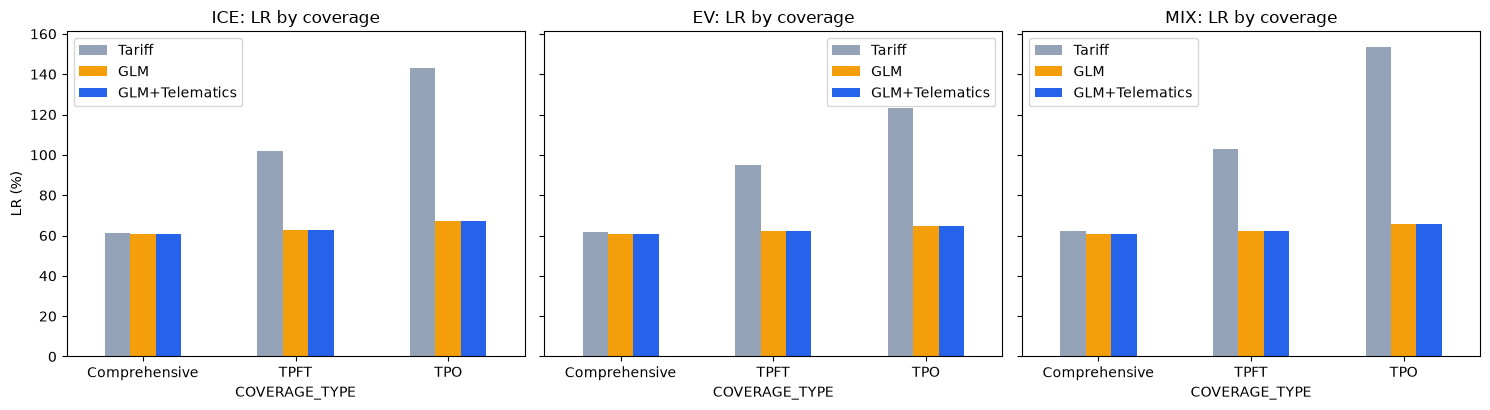

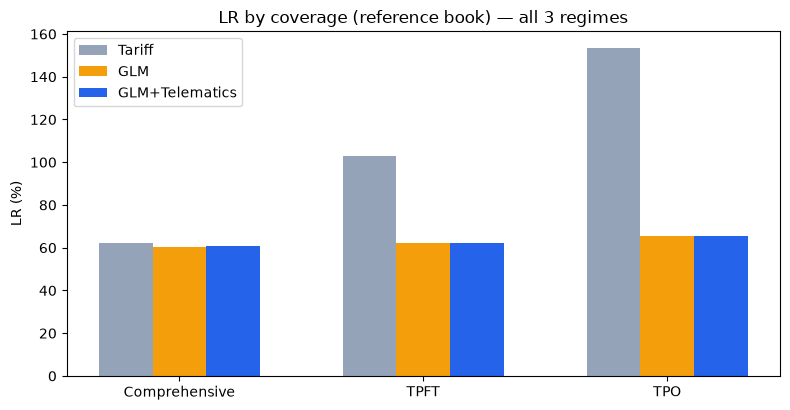

In [5]:
import numpy as np
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(scens)); w = 0.22
for i, m in enumerate(REGIMES_RUN):
    ax.bar(x + (i - 1) * w, [lr(ALL[s][1][m]) for s in scens], w, label=reg_label(m), color=reg_color(m))
ax.set_xticks(x); ax.set_xticklabels(scens)
ax.axhspan(65, 75, color='green', alpha=0.12, label='target 65-75%')
ax.set_title('Portfolio LR by scenario — all 3 regimes'); ax.set_ylabel('LR (%)')
ax.legend(); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(scens), figsize=(5 * len(scens), 4.2), sharey=True)
if len(scens) == 1: axes = [axes]
for ax, s in zip(axes, scens):
    d = pd.DataFrame({reg_label(m): lr_by(ALL[s][1][m], 'COVERAGE_TYPE') for m in REGIMES_RUN})
    d.plot.bar(ax=ax, color=[reg_color(m) for m in REGIMES_RUN], rot=0)
    ax.set_title(f'{s}: LR by coverage'); ax.set_ylabel('LR (%)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.2))
covs = ['Comprehensive', 'TPFT', 'TPO']; x = np.arange(len(covs)); w = 0.22
ref = ALL['MIX' if 'MIX' in ALL else scens[0]][1]
for i, m in enumerate(REGIMES_RUN):
    ax.bar(x + (i - 1) * w, [lr(ref[m][ref[m].COVERAGE_TYPE == c]) for c in covs],
           w, label=reg_label(m), color=reg_color(m))
ax.set_xticks(x); ax.set_xticklabels(covs)
ax.set_title('LR by coverage (reference book) — all 3 regimes')
ax.set_ylabel('LR (%)'); ax.legend(); plt.tight_layout(); plt.show()


## Monte Carlo — OPTIONAL (set `RUN_MC=True` to spend compute)
Off by default. When on: 2 frequency scenarios × 3 seeds × 3 regimes = 18 runs.

In [ ]:
RUN_MC = False; MC_SEEDS = (0, 1, 2)
if not RUN_MC:
    print("MC skipped (RUN_MC=False). Baseline above is sufficient for pricing decisions.")
else:
    import itertools
    rows = []
    for ov, s, m in itertools.product([None, {'claim_frequency_base': -1.80}], MC_SEEDS, REGIMES_RUN):
        c = copy.deepcopy(cfg)
        if ov: c.update(ov)
        b = simulate(gen(c, SCEN['MIX'], c['seed']), c, SCEN['MIX'], seed=s, verbose=False)
        b = price_book(b, m, c)
        rows.append({'scen': 'High-freq' if ov else 'Base', 'seed': s, 'regime': reg_label(m),
                     'lr': b['CLAIM_AMOUNT'].sum() / b['FINAL_PREMIUM_SST'].sum()})
    mc = pd.DataFrame(rows)
    tab = mc.groupby(['scen', 'regime'])['lr'].agg(mean='mean', p5=lambda x: x.quantile(.05),
        p95=lambda x: x.quantile(.95), P_LR_gt_75=lambda x: (x > 0.75).mean())
    display((tab * 100).round(1))
    fig, ax = plt.subplots(figsize=(9, 4.4))
    for m in REGIMES_RUN:
        ax.hist(mc[mc.regime == reg_label(m)]['lr'] * 100, bins=8, alpha=0.55, label=reg_label(m), color=reg_color(m))
    ax.axvline(75, color='red', ls='--', label='75% appetite'); ax.legend(); ax.set_xlabel('LR (%)')
    ax.set_title('MC LR distribution — all 3 regimes'); plt.tight_layout(); plt.show()


In [6]:
scen_to_export = "MIX" if "MIX" in ALL else list(ALL.keys())[0]
raw_book, books = ALL[scen_to_export]
file_name = f"VoltVision_Motor_Simulation_{scen_to_export}.xlsx"
with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    raw_book.to_excel(writer, sheet_name='Simulation Data', index=False)
    books['tariff'][['POLID', 'FINAL_PREMIUM_SST']].to_excel(writer, sheet_name='Tariff Premiums', index=False)
    books['glm'][['POLID', 'FINAL_PREMIUM_SST']].to_excel(writer, sheet_name='GLM Premiums', index=False)
    books['telem'][['POLID', 'FINAL_PREMIUM_SST']].to_excel(writer, sheet_name='Telematics Premiums', index=False)
print(f"exported {file_name}")


exported VoltVision_Motor_Simulation_MIX.xlsx


## Next
`04_analysis.ipynb` (later, complementary) builds the deep-dive on these outputs. Improvement backlog lives in `voltvision/simulate.py` + `voltvision/pricing.py` TODOs.